# Functional connectivity analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
#data_dir = '/home/alexandresayal/mnt/DATAPOOL/VPMB/BIDS-VPMB-SPE'
tc_dir = os.path.join(data_dir,'derivatives','timecourses')
#output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['UA']
hrf_delay = 0 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [3]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

df = pd.DataFrame(columns=['subject','tr','run','left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1'])

for ss,subject in enumerate(subject_list):
    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            # load timecourse
            #tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-zscoresample_ss.npy")
            #tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-psc.npy")
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-psc_detrend.npy")
            tc = np.load(tc_file)

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, tc[:,0], tc[:,1], tc[:,2], tc[:,3], tc_mean1, tc_mean2]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

In [4]:
# Estimate the correlation between the timecourses of left and right v1 and mt considering a sliding window of 6 timepoints

# Settings
sub_idx = 1
tr_idx = 2
tr = tr_list[tr_idx]
#window_size = 7.5 # in seconds
#window_size_tr = int(window_size/tr_list[tr_idx])
window_size_tr = 6
#step_size = tr_list[tr_idx] # in seconds
step_size_tr = 1

# Get timecourse
tc = df.loc[(df['subject']==subject_list[sub_idx]) & (df['tr']==tr_list[tr_idx]) & (df['run']==run_list[0])][roi_list].values
n_volumes = tc[0,0].shape[0]

# Estimate correlation
corr = np.zeros((len(roi_list),len(roi_list),int((n_volumes-window_size_tr)/step_size_tr)))

for ii in range(len(roi_list)):
    for jj in range(len(roi_list)):
        for kk in range(int((n_volumes-window_size_tr)/step_size_tr)):
            corr[ii,jj,kk] = np.corrcoef(tc[0,ii][kk*step_size_tr:kk*step_size_tr+window_size_tr],tc[0,jj][kk*step_size_tr:kk*step_size_tr+window_size_tr])[0,1]


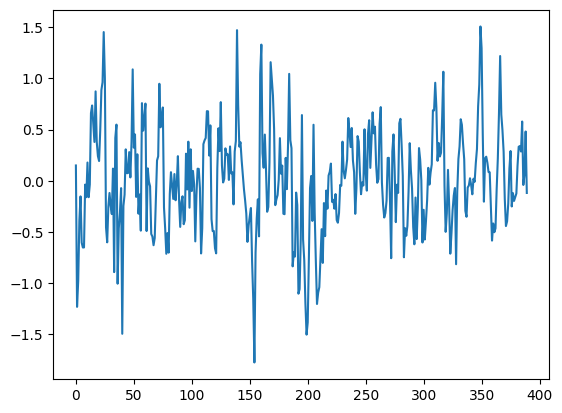

In [5]:
plt.plot(tc[0,1])


Text(0.5, 0.98, 'Subject sub-02, TR 1 s, Window size 6 vols, Step size 1 vols')

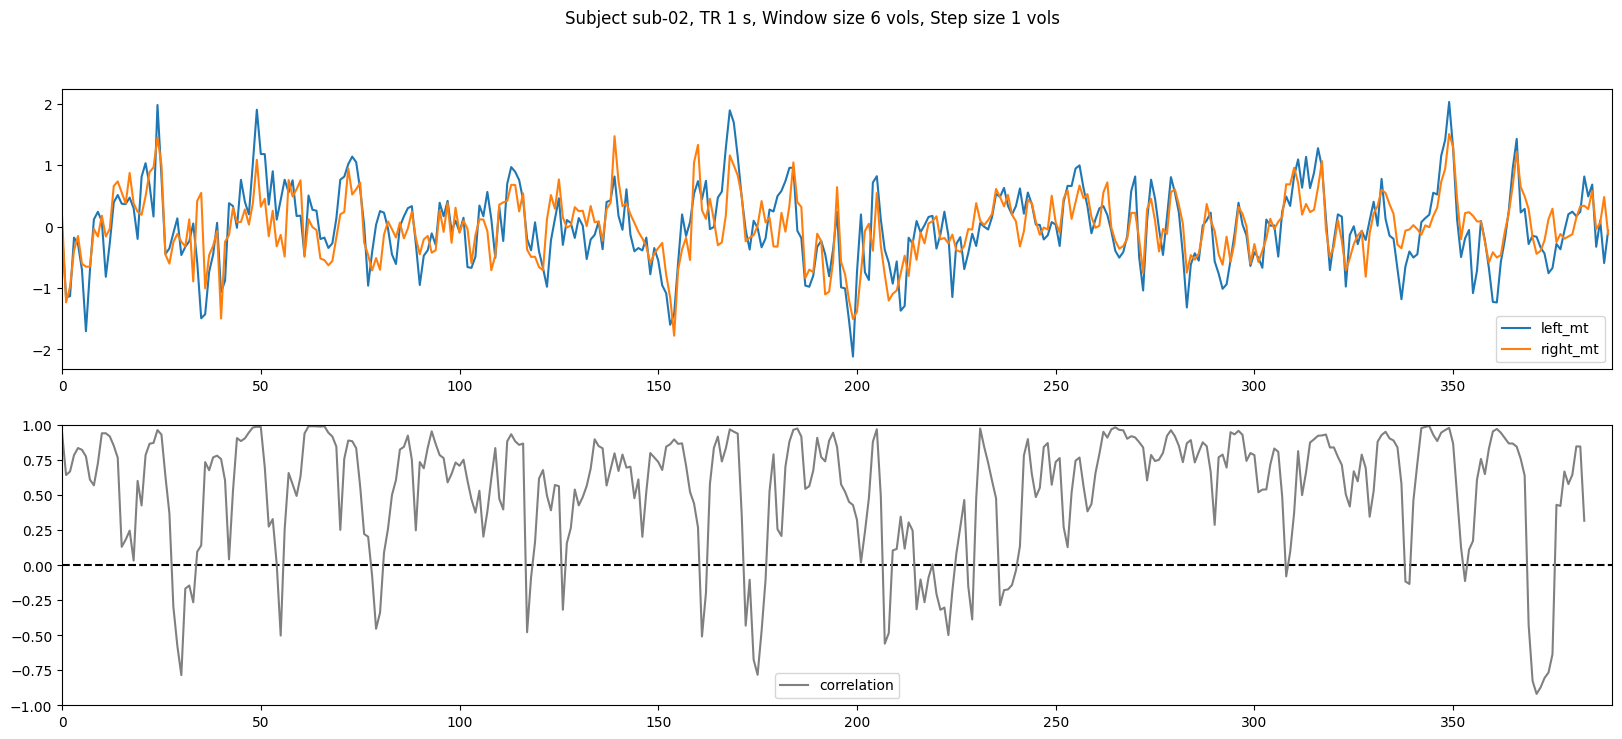

In [6]:
# Plot left mt, right mt and correlation between them as 3 subplots
fig, ax = plt.subplots(2,1,figsize=(20,8))
ax[0].plot(tc[0,0],label='left_mt')
ax[0].plot(tc[0,1],label='right_mt')
ax[0].legend()
ax[0].set_xlim([0,n_volumes])
ax[1].hlines(0,0,n_volumes,linestyle='dashed',color='black')
ax[1].plot(corr[0,1],label='correlation',color='grey')
ax[1].legend()
ax[1].set_xlim([0,n_volumes])
ax[1].set_ylim([-1,1])

fig.suptitle(f"Subject {subject_list[sub_idx]}, TR {tr_list[tr_idx]} s, Window size {window_size_tr} vols, Step size {step_size_tr} vols")

# centering at coherent switches

In [17]:
# Settings
sub_idx = 4
tr_idx = 3
tr_list = [0.5, 0.75, 1, 2.5]
tr = tr_list[tr_idx]
window_size_tr = 4
run_type = 'UA'

task_label = f'task-{run_type}_acq-{round(tr*1000):04}_run-1'
events_file = os.path.join(data_dir, subject_list[sub_idx], 'func', f'{subject_list[sub_idx]}_{task_label}_events.tsv')

events = pd.read_csv(events_file, sep='\t')

# trim events to coherent and incoherent trial_types
events = events.loc[events['trial_type'].isin(['coherent','incoherent'])]
events = events.reset_index(drop=True)

# trim events with duration < 5 seconds
events = events.loc[events['duration']>=7.5]
events = events.reset_index(drop=True)

# get the indexes (based on the TR) for all coherent and incoherent trials
coherent_idx = events.loc[events['trial_type']=='coherent']['onset'].values/tr
coherent_idx = [int(x) for x in coherent_idx]
incoherent_idx = events.loc[events['trial_type']=='incoherent']['onset'].values/tr
incoherent_idx = [int(x) for x in incoherent_idx]

# number of coherent trials
n_coherent = len(coherent_idx)
n_incoherent = len(incoherent_idx)

In [18]:
events

,onset,duration,trial_type
0,45.0,7.5,coherent
1,60.0,7.5,incoherent
2,67.5,10.0,coherent
3,82.5,7.5,incoherent
4,132.5,7.5,coherent
5,210.0,10.0,coherent
6,237.5,7.5,coherent
7,245.0,7.5,incoherent
8,267.5,7.5,coherent
9,275.0,7.5,incoherent


Text(0, 0.5, 'correlation')

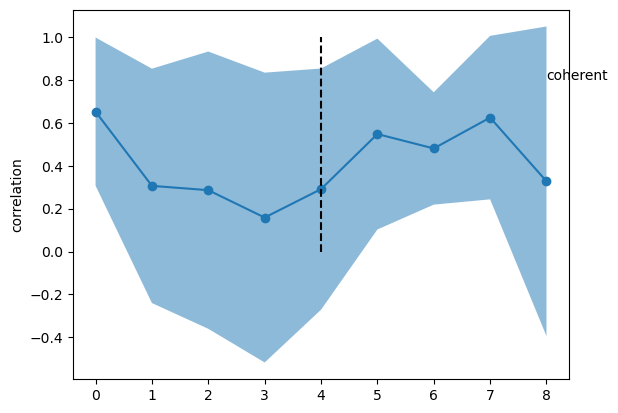

In [13]:
# get the timecourse for the 6 points around the onset of the coherent and incoherent trials
# and plot the average timecourse for each trial type

# Get timecourse
tc = df.loc[(df['subject']==subject_list[sub_idx]) & (df['tr']==tr_list[tr_idx]) & (df['run']==run_list[0])][roi_list].values
n_volumes = tc[0,0].shape[0]

corr = np.zeros((n_coherent,window_size_tr*2+1))

for jj in range(n_coherent):

    idx = coherent_idx[jj]

    # left_mt timecourse
    a = tc[0,0][idx-window_size_tr:idx+window_size_tr*2]
    # right_mt timecourse
    b = tc[0,1][idx-window_size_tr:idx+window_size_tr*2]

    # correlation per window of window_size_tr
    for tt in range(0,window_size_tr*2+1):
        corr[jj,tt] = np.corrcoef(a[tt:tt+window_size_tr],b[tt:tt+window_size_tr])[0,1]
        
# plot average + sd of the n_coherent correlation trials
plt.plot(np.mean(corr,axis=0),label='coherent',marker='o')
plt.fill_between(np.arange(0,window_size_tr*2+1),np.mean(corr,axis=0)-np.std(corr,axis=0),np.mean(corr,axis=0)+np.std(corr,axis=0),alpha=0.5)
plt.vlines(window_size_tr,0,1,linestyle='dashed',color='black')
# write 'coherent' on x = 8 y = 0.8
plt.text(8,0.8,'coherent')
plt.ylabel('correlation')


Text(0, 0.5, 'correlation')

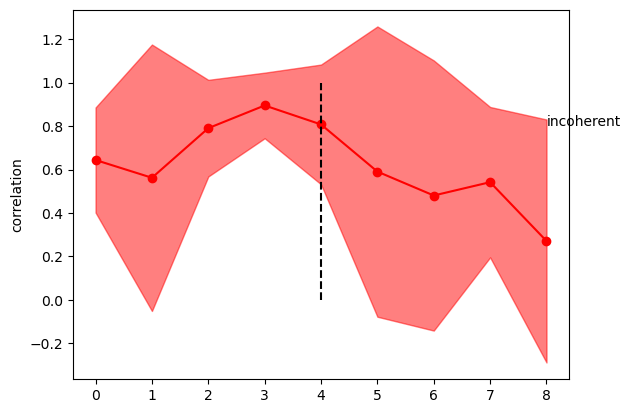

In [14]:
# get the timecourse for the 6 points around the onset of the incoherent trials
# and plot the average timecourse for each trial type

# Get timecourse
tc = df.loc[(df['subject']==subject_list[sub_idx]) & (df['tr']==tr_list[tr_idx]) & (df['run']==run_list[0])][roi_list].values
n_volumes = tc[0,0].shape[0]

corr = np.zeros((n_incoherent,window_size_tr*2+1))

for jj in range(n_incoherent):

    idx = incoherent_idx[jj]

    # left_mt timecourse
    a = tc[0,0][idx-window_size_tr:idx+window_size_tr*2]
    # right_mt timecourse
    b = tc[0,1][idx-window_size_tr:idx+window_size_tr*2]

    # correlation per window of window_size_tr
    for tt in range(0,window_size_tr*2+1):
        corr[jj,tt] = np.corrcoef(a[tt:tt+window_size_tr],b[tt:tt+window_size_tr])[0,1]
        
# plot average + sd of the n_coherent correlation trials
plt.plot(np.mean(corr,axis=0),label='incoherent',marker='o',color='red')
plt.fill_between(np.arange(0,window_size_tr*2+1),np.mean(corr,axis=0)-np.std(corr,axis=0),np.mean(corr,axis=0)+np.std(corr,axis=0),alpha=0.5,color='red')
plt.vlines(window_size_tr,0,1,linestyle='dashed',color='black')
# write 'coherent' on x = 8 y = 0.8
plt.text(8,0.8,'incoherent')
plt.ylabel('correlation')
